---
title: "Gaussianity diagnostics"
short_title: "06 · Diagnostics"
subtitle: "Did we actually reach N(0, I)? QQ-plots, moments, negentropy, and a multivariate energy test"
description: >
  The capstone of Part 0: how to measure whether a density destructor reached
  N(0, I). Per-coordinate QQ-plots and skew/kurtosis, negentropy as RBIG's
  information-theoretic stopping signal, and an energy-distance test of joint
  multivariate normality that falls monotonically as RBIG iterates.
---

(sec-nb-06)=
# 06 — Gaussianity diagnostics

We can build a density destructor ([notebook 04](04_density_destructors.ipynb))
and trust its arithmetic ([notebook 05](05_numerical_mechanics.ipynb)). The
last foundational question is **how do we know it worked?** — that the
pushforward $z = T(x)$ really is $\mathcal{N}(0, I)$. Gaussianity has two
levels, and we need a diagnostic for each: per-coordinate (are the *marginals*
standard normal?) and joint (is the *whole vector* multivariate normal, i.e.
also independent across coordinates?).

**What you will see**

- **Marginal**: QQ-plots and skewness / excess-kurtosis, before vs. after.
- **Negentropy** as the information-theoretic non-Gaussianity — RBIG's classic
  stopping signal — and why it is noisy to estimate near convergence.
- **Joint**: an energy-distance test against $\mathcal{N}(0, I)$ that falls
  monotonically as RBIG adds layers (Henze–Zirkler is the classical alternative).

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.datasets import make_moons

import rbig
from _style import GAUSS_KW, style_ax

rng = np.random.default_rng(7)

X, _ = make_moons(5000, noise=0.06, random_state=0)
X = (X - X.mean(0)) / X.std(0)

# Fit a density destructor and grab the pushforward + intermediate states.
model = rbig.AnnealedRBIG(n_layers=50, rotation="random", random_state=0)
model.fit(X)


def through_layers(k):
    s = X
    for layer in model.layers_[:k]:
        s = layer.transform(s)
    return s


Z = through_layers(len(model.layers_))  # fully Gaussianized

## 1. Marginal diagnostics: QQ-plots and moments

The first, cheapest check is per-coordinate. A **QQ-plot** sorts the samples
and plots them against the matching standard-normal quantiles $\Phi^{-1}((i -
0.5)/n)$; if the coordinate is $\mathcal{N}(0,1)$ the points fall on the
identity line. Two scalar summaries back it up: **skewness** $\gamma_1$
(asymmetry) and **excess kurtosis** $\gamma_2$ (tail weight), both $0$ for a
Gaussian.

                skewness   excess kurtosis
data x            0.0006            1.0627
Gaussianized z      0.0003            0.0109


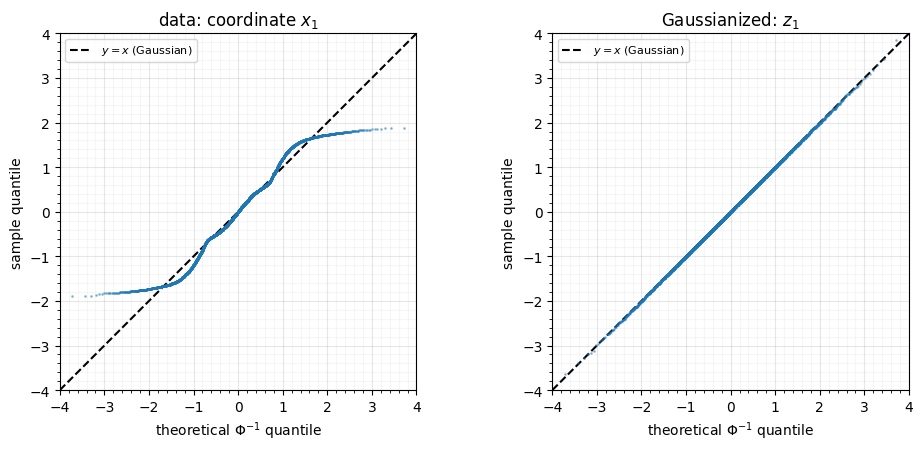

In [2]:
def qq(ax, samples, title):
    s = np.sort(samples)
    q_theory = stats.norm.ppf((np.arange(1, len(s) + 1) - 0.5) / len(s))
    ax.plot([-4, 4], [-4, 4], **GAUSS_KW, label="$y=x$ (Gaussian)")
    ax.plot(q_theory, s, ".", ms=2, alpha=0.4, color="tab:blue")
    ax.set(title=title, xlabel="theoretical $\\Phi^{-1}$ quantile",
           ylabel="sample quantile", xlim=(-4, 4), ylim=(-4, 4))
    ax.set_aspect("equal")
    ax.legend(loc="upper left", fontsize=8)
    style_ax(ax)


fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
qq(axes[0], X[:, 0], "data: coordinate $x_1$")
qq(axes[1], Z[:, 0], r"Gaussianized: $z_1$")
fig.tight_layout()

print(f"{'':12s}{'skewness':>12s}{'excess kurtosis':>18s}")
for name, d in [("data x", X), ("Gaussianized z", Z)]:
    print(f"{name:12s}{np.abs(stats.skew(d)).mean():12.4f}"
          f"{np.abs(stats.kurtosis(d)).mean():18.4f}")

The data QQ-plot is S-shaped — the two-moons marginal is platykurtic (light
tails, excess kurtosis $< 0$) and bends away from the line. After
Gaussianization the points snap onto $y = x$, and the mean $|\gamma_1|,
|\gamma_2|$ both collapse toward $0$. QQ-plots catch *what kind* of
non-Gaussianity remains (skew vs. tails); the moments put a number on it.

## 2. Negentropy: the information-theoretic stopping signal

Moments only probe the 3rd and 4th order. The complete per-coordinate
non-Gaussianity is the **negentropy** $J(p) = H(\mathcal{N}_{\sigma}) - H(p)
\ge 0$ from [notebook 03](03_why_standard_gaussian.ipynb), and the complete
*joint* non-Gaussianity is the KL to the standard normal, which decomposes as

$$
\mathrm{KL}\big(p \,\|\, \mathcal{N}(0, I)\big)
= \underbrace{\mathrm{TC}(p)}_{\text{dependence}}
+ \underbrace{\textstyle\sum_i J(p_i)}_{\text{marginal non-Gaussianity}}.
$$

Driving this to $0$ *is* the RBIG objective, and `rbig` uses the per-layer
information reduction as its **stopping criterion** {cite}`laparra2011rbig`. We
estimate negentropy with `rbig.negentropy` on the data and on the pushforward.

sum negentropy  — data        : 0.3181 nats
sum negentropy  — Gaussianized: 0.0001 nats  (~0)


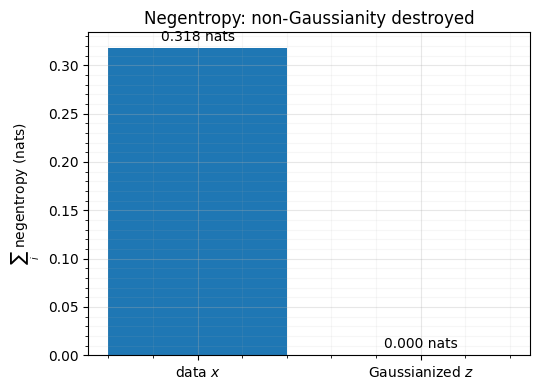

In [3]:
neg_data = float(np.sum(np.clip(rbig.negentropy(X), 0, None)))
neg_gauss = float(np.sum(np.clip(rbig.negentropy(Z), 0, None)))
print(f"sum negentropy  — data        : {neg_data:.4f} nats")
print(f"sum negentropy  — Gaussianized: {neg_gauss:.4f} nats  (~0)")

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(["data $x$", "Gaussianized $z$"], [neg_data, neg_gauss],
              color=["tab:blue", "tab:green"])
ax.bar_label(bars, fmt="%.3f nats", padding=3)
ax.set(ylabel=r"$\sum_i$ negentropy (nats)",
       title="Negentropy: non-Gaussianity destroyed")
style_ax(ax)
fig.tight_layout()

:::{warning} Negentropy is principled but high-variance
Negentropy is the *right* target, but estimating it from samples (here via
histogram entropies) is noisy — especially on the *near-Gaussian* intermediate
states partway through RBIG, where the true signal is tiny. That variance is
why a clean per-layer negentropy curve is hard to draw, and why in practice we
also watch a robust two-sample test of joint normality, next.
:::

## 3. Joint normality: an energy-distance test

Marginal checks can all pass while the joint is still structured (think of a
rotated non-Gaussian whose axes happen to look normal). For the joint verdict
we compare the pushforward $Z$ to a fresh $\mathcal{N}(0, I)$ sample with the
**energy distance** — a kernel two-sample statistic that is $0$ iff the two
distributions match:

$$
\mathcal{E}(Z, G) = 2\,\mathbb{E}\lVert Z - G\rVert
  - \mathbb{E}\lVert Z - Z'\rVert - \mathbb{E}\lVert G - G'\rVert \;\ge\; 0.
$$

(The classical **Henze–Zirkler** test is the textbook alternative
{cite}`coverThomas2006`; the energy distance is easy to compute from scratch
and needs no distributional table.) We track it as RBIG adds layers.

energy distance to N(0,I):  data = 0.0497  ->  final = 0.0030  (sampling floor)


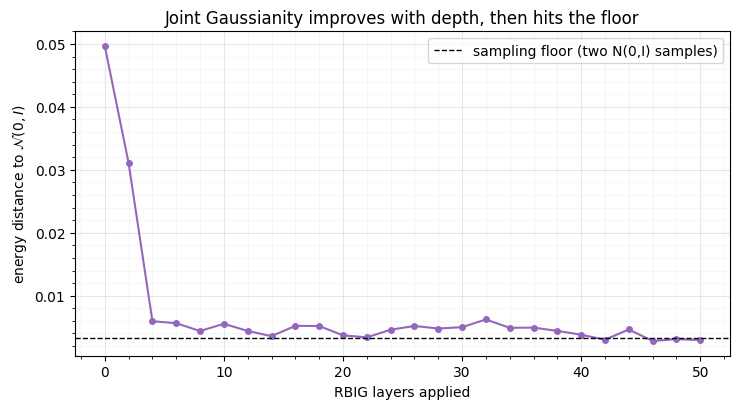

In [4]:
def energy_distance(A, B):
    """Multivariate energy distance between samples A and B (>= 0, 0 iff equal)."""
    def mean_pairwise(P, Q):
        return np.sqrt(((P[:, None, :] - Q[None, :, :]) ** 2).sum(-1)).mean()
    return (2 * mean_pairwise(A, B)
            - mean_pairwise(A, A) - mean_pairwise(B, B))


def avg_energy(state, n_draws=6, n=800):
    """Average the energy distance over several N(0,I) draws to tame estimator noise."""
    vals = []
    for _ in range(n_draws):
        idx = rng.choice(len(state), n, replace=False)
        vals.append(max(energy_distance(state[idx], rng.standard_normal((n, 2))), 0.0))
    return float(np.mean(vals))


layers = np.arange(0, len(model.layers_) + 1, 2)
energy = np.array([avg_energy(through_layers(k)) for k in layers])

print(f"energy distance to N(0,I):  data = {energy[0]:.4f}  ->  "
      f"final = {energy[-1]:.4f}  (sampling floor)")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(layers, energy, "-o", color="tab:purple", ms=4)
ax.axhline(energy[-5:].mean(), color="k", ls="--", lw=1,
           label="sampling floor (two N(0,I) samples)")
ax.set(xlabel="RBIG layers applied", ylabel=r"energy distance to $\mathcal{N}(0,I)$",
       title="Joint Gaussianity improves with depth, then hits the floor")
ax.legend()
style_ax(ax)
fig.tight_layout()

The energy distance falls steadily from the tangled two-moons toward the
noise floor (the residual is the finite-sample distance between two genuine
$\mathcal{N}(0, I)$ samples). This is the joint analogue of the per-layer
information reduction: a single, robust number that says "keep adding layers"
until it stops dropping — the practical stopping rule when negentropy is too
noisy to trust.

## Recap

| level | diagnostic | Gaussian value | tool |
|---|---|---|---|
| marginal shape | QQ-plot | points on $y=x$ | `numpy` + `scipy.stats` |
| marginal moments | skewness, excess kurtosis | $0,\ 0$ | `scipy.stats.skew/kurtosis` |
| marginal info | negentropy $J(p_i)$ | $0$ | `rbig.negentropy` |
| dependence | total correlation | $0$ | `rbig.total_correlation` |
| joint | energy distance / Henze–Zirkler | $0$ | from scratch |

:::{note} End of Part 0 — Foundations
You now have the full conceptual toolkit: the change-of-variables formula and
its additive log-det, the forward/inverse trade-off and how to differentiate a
solver, why $\mathcal{N}(0, I)$ is the target, what a density destructor is, how
to keep one numerically stable, and how to certify it converged. **Part 1**
builds the first real component in earnest — the 1D marginal transforms
($\Phi^{-1}\circ F$) that every method here stacks.
:::